# ResNet50: Training the model
## Loading python modules

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import models, transforms,datasets
from torchvision.models import ResNet50_Weights
from PIL import Image
from torch.utils.data import DataLoader
import prettypyplot as pplt
import seaborn as sns
import torch.optim as optim
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import torch.nn.functional as F

## Loading datasets

In [2]:
transform=transforms.Compose([transforms.Resize((224,224)),transforms.ToTensor()])
dataset_train=datasets.ImageFolder(root='../train_oversampling',transform=transform)
class_names=dataset_train.classes
dataset_test=datasets.ImageFolder(root='../test',transform=transform)
print(dataset_test.classes)
dataset_val=datasets.ImageFolder(root='../val',transform=transform)
dataloader_train=DataLoader(dataset_train,batch_size=32,shuffle=True)
dataloader_test=DataLoader(dataset_test,batch_size=32,shuffle=True)
dataloader_val=DataLoader(dataset_val,batch_size=32,shuffle=True)

['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


## Defining the model and loading the weights

In [3]:
weights = ResNet50_Weights.DEFAULT
model=models.resnet50(weights=weights)
for pram in model.parameters():
    pram.requires_grad=False
for param in model.layer4.parameters():
    param.requires_grad = True
    
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [4]:
num_classes=8
model.fc=nn.Linear(model.fc.in_features,num_classes)
# if torch.cuda.device_count() > 1:
#     model = nn.DataParallel(model)
device = 'cpu'#"cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [5]:
preprocess = weights.transforms()
criterion=nn.CrossEntropyLoss()
X_batch,y_batch=next(iter(dataloader_train))
y_pred=model(preprocess(X_batch.to(device)))
criterion(y_pred,y_batch.to(device))

tensor(2.0803, grad_fn=<NllLossBackward0>)

In [25]:
model = torch.load('resnet_model_free_lastlayer.pth',weights_only=False,map_location=torch.device('cpu'))
if isinstance(model, torch.nn.DataParallel):
    model = model.module


In [20]:
optimizer=optim.Adam(model.parameters(),lr=0.001)
scheduler=optim.lr_scheduler.ReduceLROnPlateau(optimizer,
  mode='min',
  factor=0.1,
  patience=5,
  verbose=True)

TypeError: ReduceLROnPlateau.__init__() got an unexpected keyword argument 'verbose'

In [ ]:
class EarlyStopper:
    def __init__(self, patience=1, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float('inf')

    def early_stop(self, validation_loss):
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

In [ ]:
epochs=100
early_stopper = EarlyStopper(patience=5)
train_loss,train_acc=[],[]
validation_loss,validation_acc=[],[]
for epoch in range(epochs):
    model.train()
    total_loss=0
    correct=0
    total=0
    progress_bar=tqdm(dataloader_train,desc='Epoch {:1d}'.format(epoch),leave=True)
    for i, batch in enumerate(progress_bar):
        X_batch,y_batch=batch
        X_batch=preprocess(X_batch.to(device))
        y_batch=y_batch.to(device)
        model.zero_grad()
        y_pred=model(X_batch.to(torch.float32))
        loss=criterion(y_pred,y_batch)
        loss.backward()
        optimizer.step()
        total_loss+=loss.item()
        _, predicted = torch.max(y_pred, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)
        progress_bar.set_postfix({"training_loss": "{:.3f}".format(total_loss/(i+1)),"accuracy": "{:.2f}%".format(100 * correct / total)})
    train_accuracy = 100 * correct / total
    train_loss.append(total_loss/len(dataloader_train))
    train_acc.append(correct/total)
    model.eval()
    val_loss=0
    val_correct=0
    val_total=0
    with torch.no_grad():
        for X_val,y_val in dataloader_val:
            X_val, y_val = preprocess(X_val.to(device)), y_val.to(device)
            outputs = model(X_val.to(torch.float32))
            loss = criterion(outputs, y_val)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == y_val).sum().item()
            val_total += y_val.size(0)
    val_loss /= len(dataloader_test)
    val_accuracy = 100 * val_correct / val_total
    validation_loss.append(val_loss)
    validation_acc.append(val_correct/val_total)
    scheduler.step(val_loss)
    print(f"Epoch {epoch+1}/{epochs} | "
      f"Train Loss: {total_loss/len(dataloader_train):.4f} | "
      f"Train Acc: {train_accuracy:.2f}% | "
      f"Val Loss: {val_loss:.4f} | "
      f"Val Acc: {val_accuracy:.2f}%")
    
    if early_stopper.early_stop(val_loss):             
        break

Epoch 0:   0%|          | 0/583 [00:00<?, ?it/s]

Epoch 1/100 | Train Loss: 0.1632 | Train Acc: 95.08% | Val Loss: 0.0644 | Val Acc: 97.97%


Epoch 1:   0%|          | 0/583 [00:00<?, ?it/s]

Epoch 2/100 | Train Loss: 0.0411 | Train Acc: 98.66% | Val Loss: 0.0653 | Val Acc: 97.70%


Epoch 2:   0%|          | 0/583 [00:00<?, ?it/s]

...

Epoch 6/100 | Train Loss: 0.0112 | Train Acc: 99.61% | Val Loss: 0.0517 | Val Acc: 98.48%


Epoch 6:   0%|          | 0/583 [00:00<?, ?it/s]

Epoch 7/100 | Train Loss: 0.0097 | Train Acc: 99.70% | Val Loss: 0.0562 | Val Acc: 98.56%


Epoch 7:   0%|          | 0/583 [00:00<?, ?it/s]

Epoch 8/100 | Train Loss: 0.0128 | Train Acc: 99.57% | Val Loss: 0.0609 | Val Acc: 98.21%


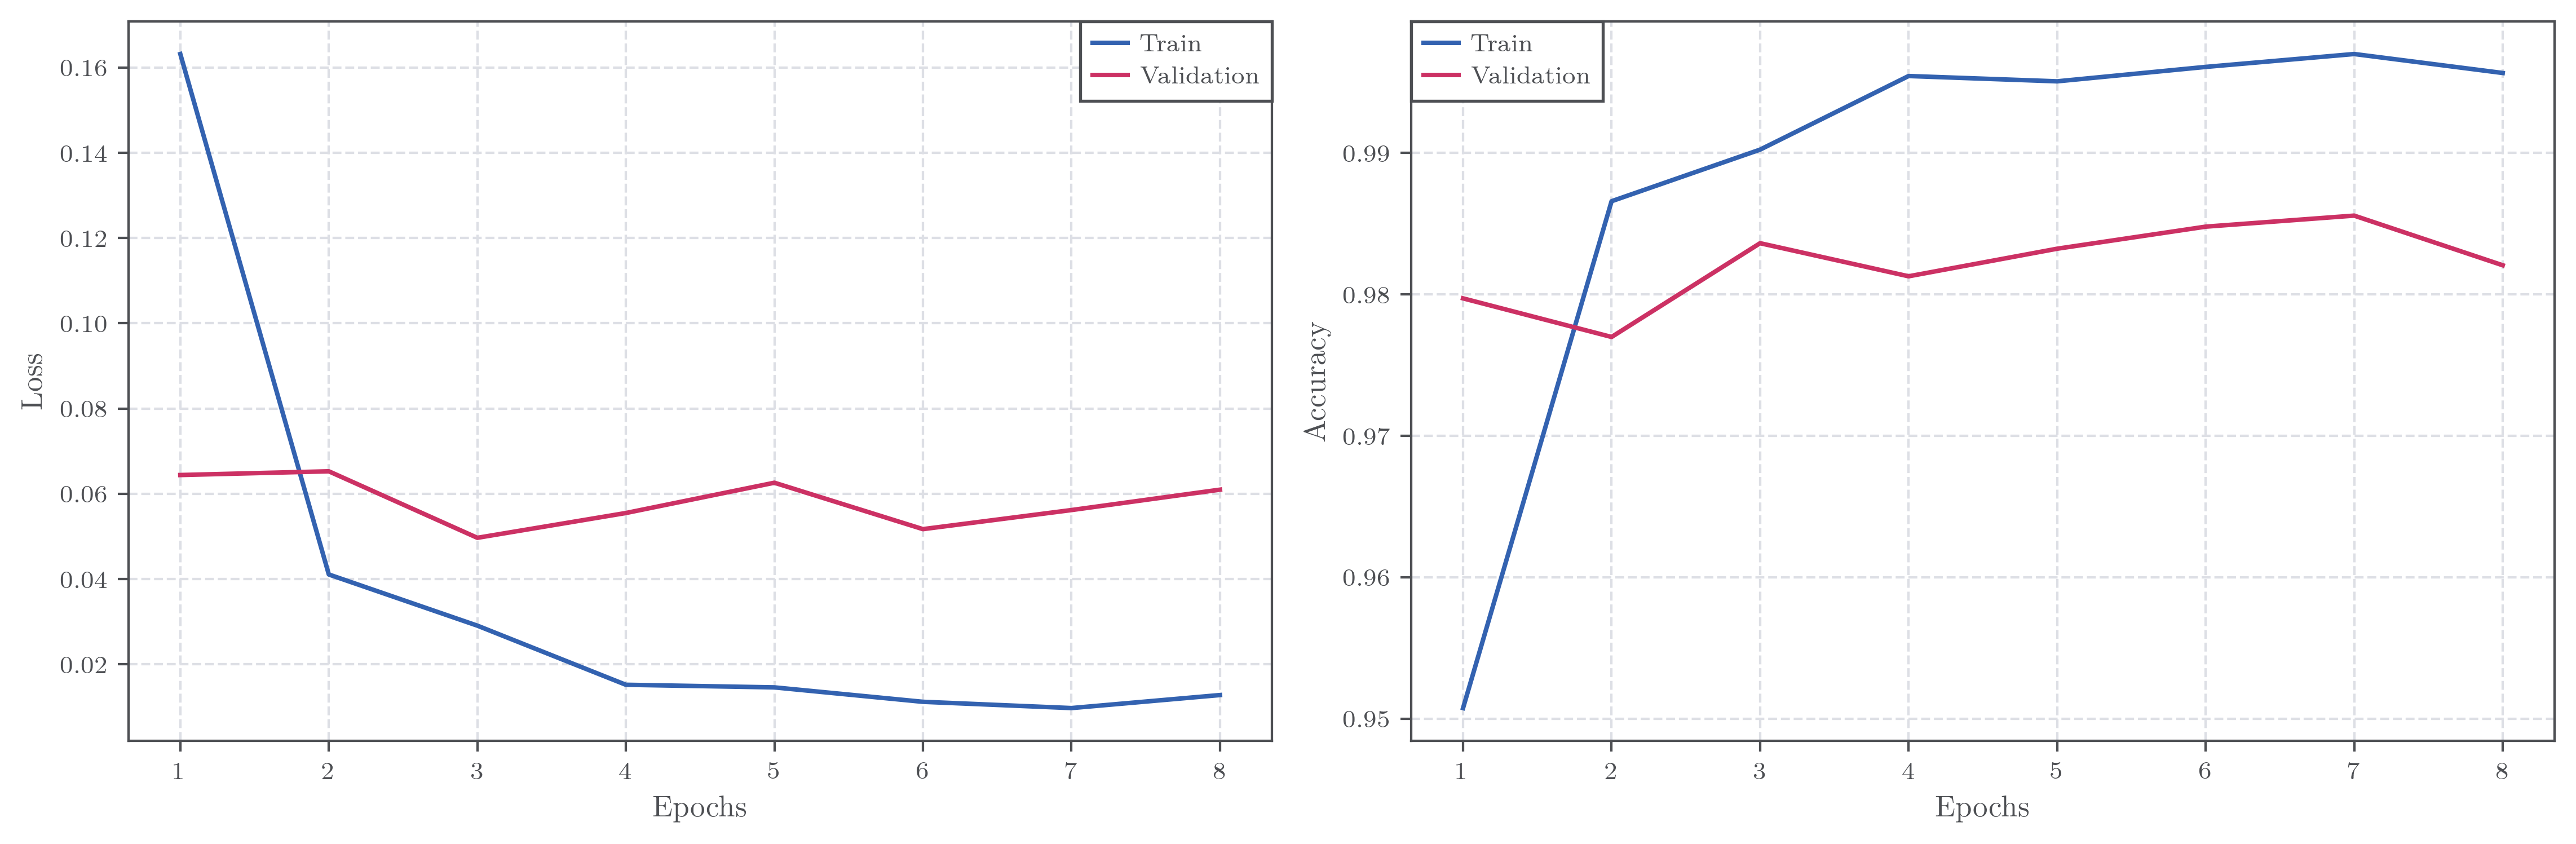

In [28]:
pplt.use_style()
data=np.loadtxt('./history_resnet50_free_lastlayer.txt')
train_loss,train_acc,validation_loss,validation_acc=data[:,0],data[:,1],data[:,2],data[:,3]
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.plot(np.arange(len(train_loss))+1,train_loss,label='Train')
plt.plot(np.arange(len(validation_loss))+1,validation_loss,label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend();
plt.subplot(122)
plt.plot(np.arange(len(train_acc))+1,train_acc,label='Train')
plt.plot(np.arange(len(validation_acc))+1,validation_acc,label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
pplt.savefig('loss_acc_resnet_free_lastlater.pdf');

In [26]:
def evaluate(dataloader_val):
    # Pass the model for evaluation
    model.eval()
    # Calculate the total loss
    loss_val_total = 0
    # Store predictions and true values.
    predictions, true_vals = [], []
    for batch in dataloader_val:
        X_batch, y_batch = batch
        X_batch = preprocess(X_batch.to('cpu'))
        y_batch = y_batch.to('cpu')
        with torch.no_grad():
            # Model prediction for a given batch
            y_pred = model(X_batch.to(torch.float32))
        # Calculating the loss function to use it as a metric
        loss = criterion(y_pred, y_batch)
        # Accumulate the loss function of all data batches.
        loss_val_total += loss.item()
        # Save predictions to use them later
        predictions.extend(y_pred.detach().cpu().numpy())
        # Save the real values ​​to use them later
        true_vals.extend(y_batch.cpu().numpy())

    # Loss of val dataset
    loss_val_avg = loss_val_total / len(dataloader_val)
    # Set of predictions from the dataset
    predictions = np.array(predictions)
    # Id prediction
    predictions = np.argmax(predictions, axis=-1)
    # Set of true values ​​of the dataset
    true_vals = np.array(true_vals)
    return true_vals,predictions#{"loss":loss_val_avg, "accuracy":accuracy_score(true_vals, predictions)}

class_names=dataset_train.classes
y_true,y_pred = evaluate(dataloader_test)
print(classification_report(y_true, y_pred, target_names=class_names))
# print(f"Loss: {metrics['loss']}")
# print(f"Accuracy: {metrics['accuracy']}")

              precision    recall  f1-score   support

    basophil       0.99      0.97      0.98       183
  eosinophil       1.00      1.00      1.00       468
erythroblast       0.99      0.97      0.98       233
          ig       0.97      0.96      0.96       435
  lymphocyte       0.97      1.00      0.98       183
    monocyte       0.98      0.99      0.98       214
  neutrophil       0.96      0.98      0.97       500
    platelet       1.00      0.99      1.00       353

    accuracy                           0.98      2569
   macro avg       0.98      0.98      0.98      2569
weighted avg       0.98      0.98      0.98      2569



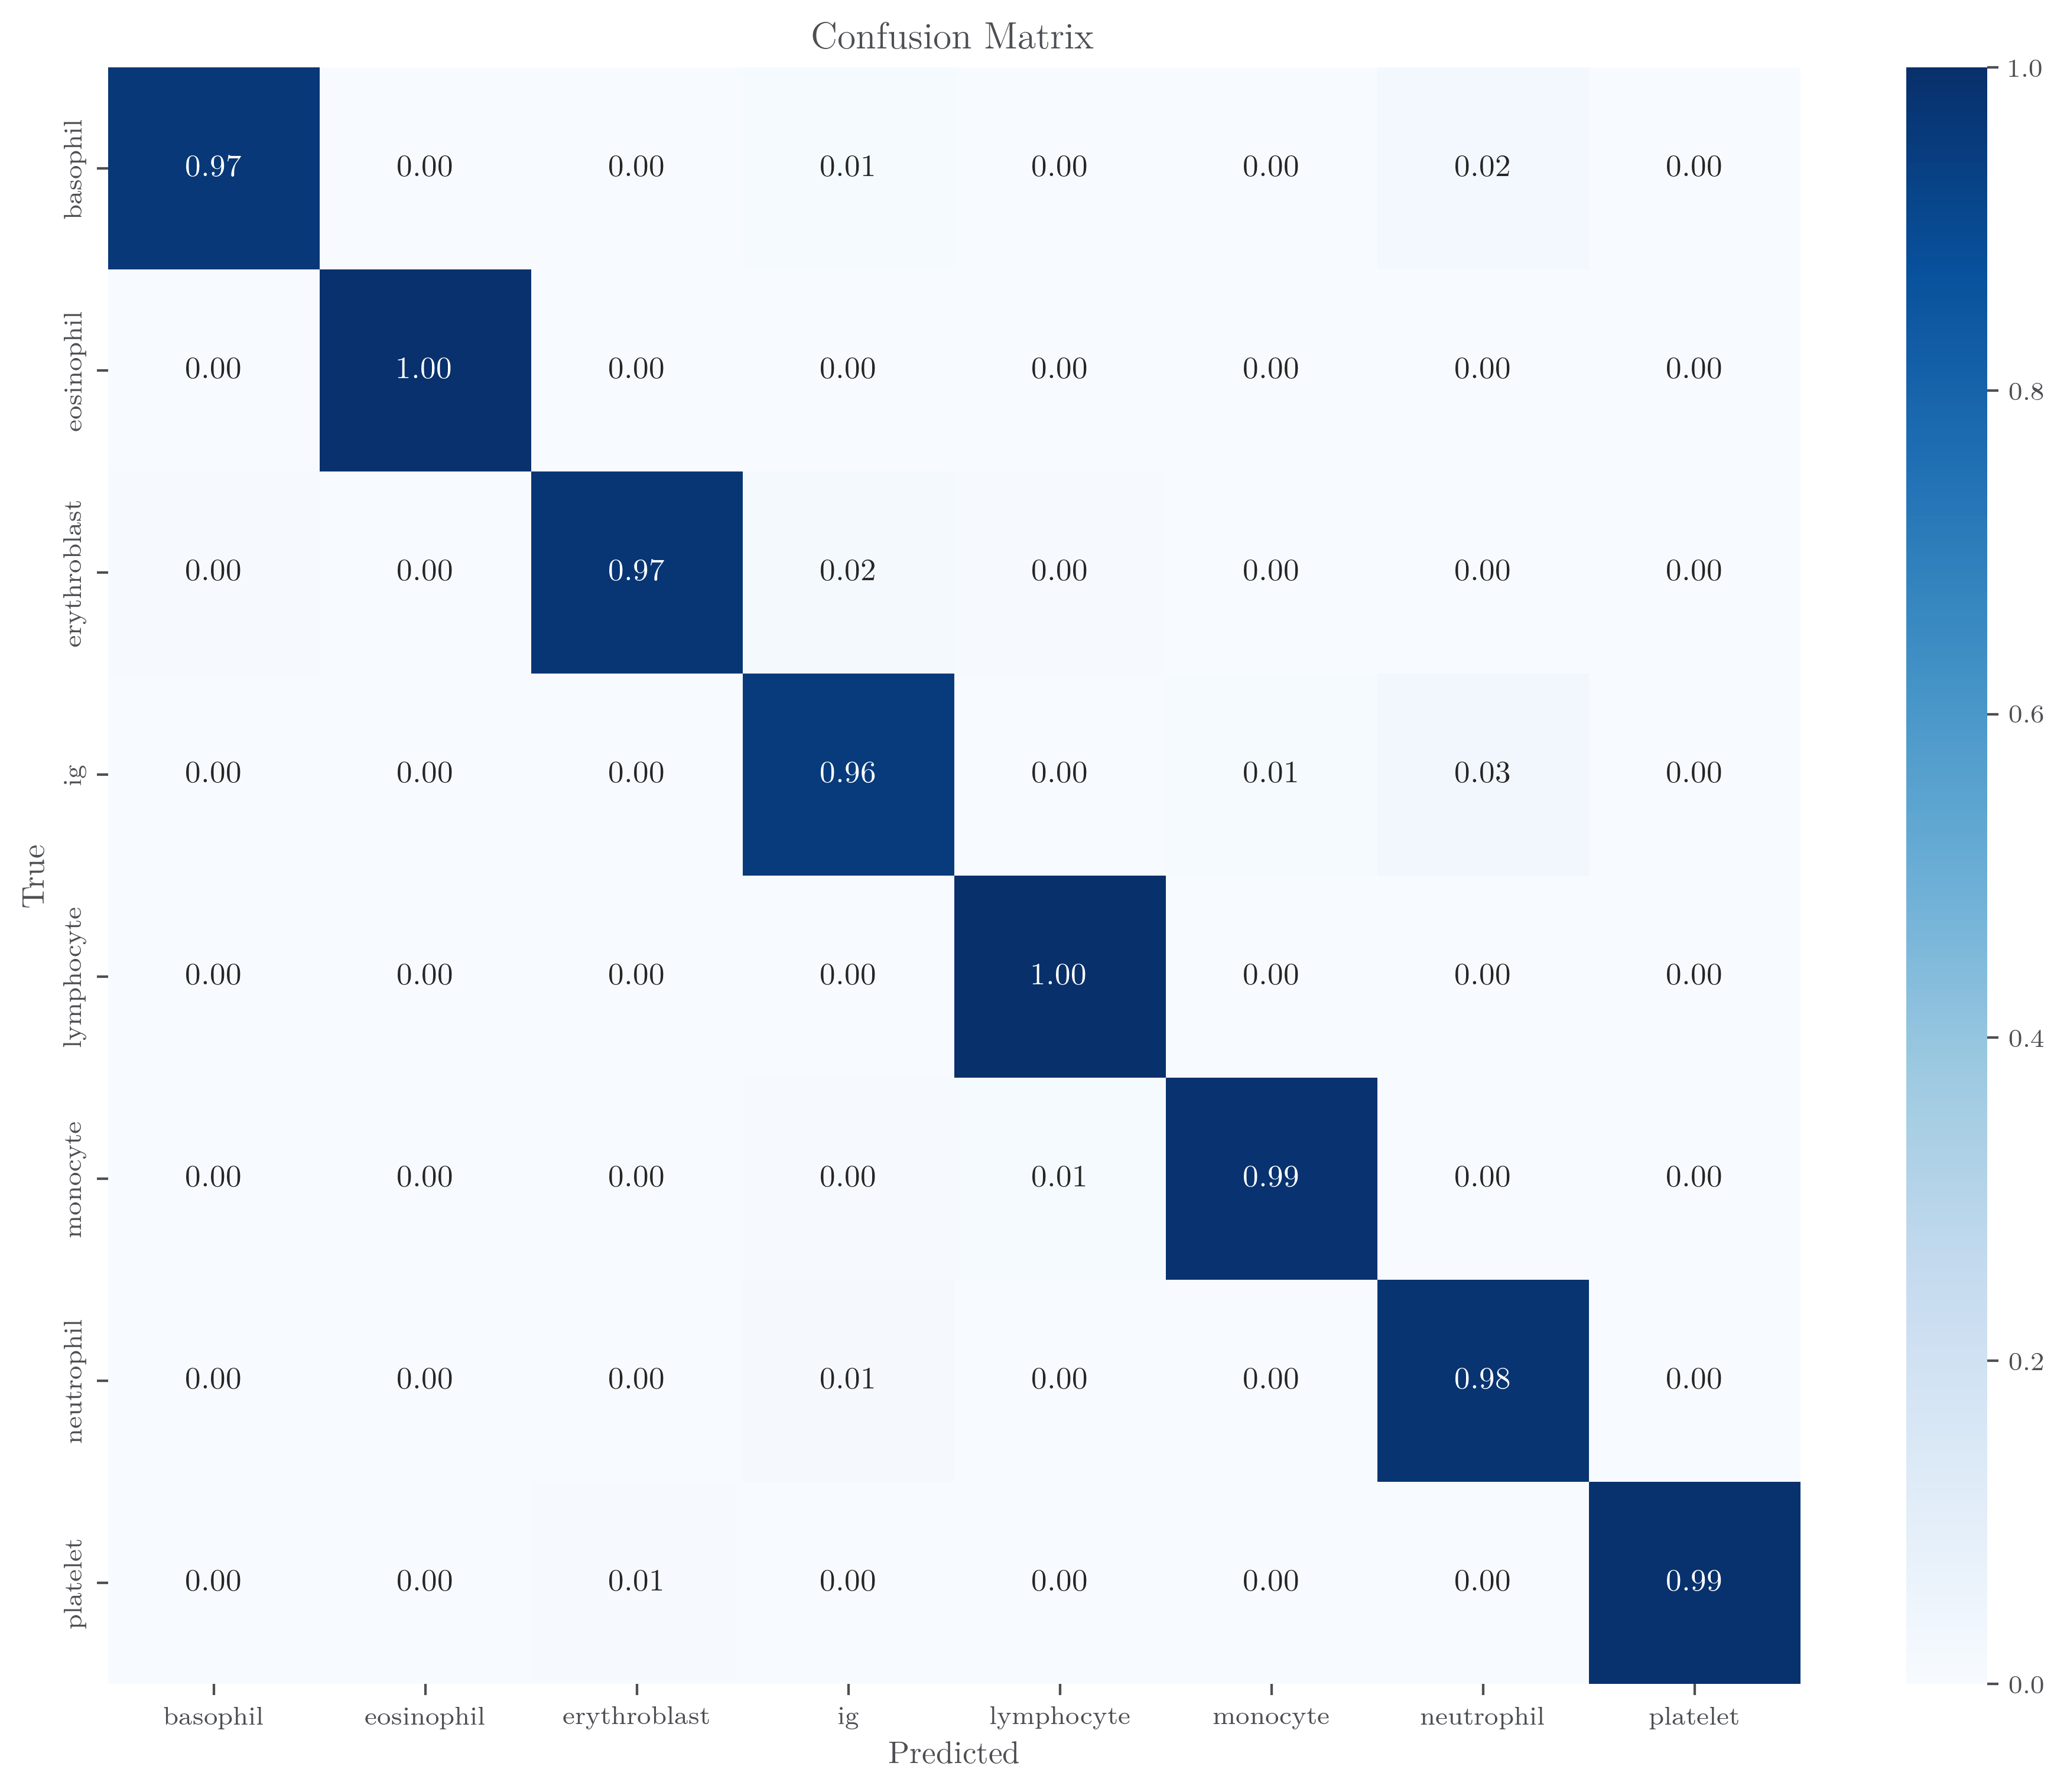

In [27]:
cm = confusion_matrix(y_true, y_pred,normalize='true')
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, xticklabels=class_names, yticklabels=class_names, fmt='.2f', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
#plt.xticks(rotation=45)
plt.title('Confusion Matrix')
pplt.savefig('cm_resnet_free_lastlayer.pdf')
plt.show()

In [14]:
torch.save(model, 'resnet_model_free_lastlayer.pth')

In [15]:
torch.save(model.state_dict(), 'resnet_model_weights_free_lastlayer.pth')

In [16]:
with open('history_resnet50_free_lastlayer.txt', 'w') as f:
    for a, b, c, d in zip(train_loss, train_acc, validation_loss, validation_acc):
        f.write(f"{a}\t{b}\t{c}\t{d}\n")